In [55]:
from hplib import hplib as hpl
# import hplib_database as db
import pandas as pd
import numpy as np


# Defining methods

In [56]:
# ambient temperature for the location

import requests


def get_ambient_temperature(
    latitude: float,
    longitude: float,
    year: int
) -> pd.Series:
    """
    Get hourly ambient air temperature for a given location and year.

    Parameters
    ----------
    latitude : float
        Latitude in WGS84.
    longitude : float
        Longitude in WGS84.
    year : int
        Year for which the temperature data is requested.

    Returns
    -------
    pd.Series
        Hourly ambient temperature in °C, indexed by local time.

    Notes
    -----
    Uses Open-Meteo's Historical Weather API with ERA5-Land.
    ERA5-Land provides hourly data at approximately 11 km resolution.
    """

    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m",
        "temperature_unit": "celsius",
        "timezone": "Europe/Berlin",
        "models": "era5_land",
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()

    temperature = pd.Series(
        data["hourly"]["temperature_2m"],
        index=pd.to_datetime(data["hourly"]["time"]),
        name="ambient_temperature",
    )

    return temperature


In [57]:
T_amb = get_ambient_temperature(latitude=52.5200, longitude=13.4050, year=2022)

In [58]:
def calc_cop_carnot(T_sink_k, T_source_k):
    """
    Calculate the Carnot Coefficient of Performance (COP) for a heat pump.
    ----
    T_sink_k : pd.series or np.array
        Sink temperature in Kelvin.
    T_source_k : pd.series or np.array
        Source temperature in Kelvin.
    """
    return T_sink_k / (T_sink_k - T_source_k)


In [59]:
def calc_COP(T_source, hp_model, T_sink = None,hp_limits=None):
    #TODO: fix a maximum COP

    """
    Calcultes the COP of a heat pump based on its carnot efficiency and provided limts.
    - Determines sink temperaturs based on a generic heating curve for low temperature heat pumps
    - Calculates COP based on carnot efficiency

    Assumes high temperature heat pumps can achieve the sink temperature always. Reality is not always so, but this simplification might be acceptable for now, wih the result in such cases being worse COPs.

    --------
    Parameters
    ----------
    T_source : array-like or scalar
        Source temperature(s) in Celsius.
    T_sink : array-like or scalar, optional
        Required for high temperature heat pumps.\
    hp_model : str
        Heat pump model type,
        lt : low temperature heat pump, uses a heating curve to determine T_sink
        ht:  high temperature heat pump
    """
    perf_df = pd.DataFrame({}) #adding to a df, to make debugging or proof-checking easier
    if hp_limits is None: 
        hp_limits = {
            'COP' : 3.0,
            'Op_point' : [5,35], #source,sink
            'low_limit' : -5,
            'high_limit' : 65
        }
        print("No hp_limits provided, using defaults\n", hp_limits)

    T_source = np.array(T_source)  # Ensure T_source is a numpy array for interpolation

    #T_sink determined with heating curve for low temp HPs
    if 'lt' in hp_model.lower():
        print(f'\n Low temperature heat pump model detected')
        heating_curve = {'T_amb': [-10, 15], 'T_supply':[45,20]} #example heating curve for low temperature air/water heat pump        
        T_sink = np.interp(T_source, heating_curve['T_amb'], heating_curve['T_supply'])

    else:
        # could remove this, and enforce correct length of T_sink, but for now, just a warning
        #converting single scalar T_sink value to array of same length as T_source, only if T_source is also a series
        if type(T_sink) is int or type(T_sink) is float:
            if type(T_source) is not int or type(T_source) is not float:
                T_sink = np.array([T_sink] * len(T_source)) 
        if len(T_sink) != len(T_source):
            raise ValueError("T_sink must be the same length as T_source.")
        if T_sink is None:
            raise ValueError("T_sink must be provided for non-low temperature heat pumps.")

    #converting temperatures to Kelvin for cop calculation
    T_sink_k = T_sink + 273.15
    T_source_k = T_source + 273.15

    #Determining cop using carnot efficiency

    ## 2nd law efficiency, based on nominal cop
    eta_2 = hp_limits['COP']/calc_cop_carnot(hp_limits['Op_point'][1] + 273.15, hp_limits['Op_point'][0] + 273.15)
    print(f"eta_2: {eta_2}")

    cop = eta_2 * calc_cop_carnot(T_sink_k, T_source_k)

    #Applying operational limits
    low_limit = hp_limits.get('low_limit', None)
    high_limit = hp_limits.get('high_limit', None)
    if low_limit is not None:
        low_limit = low_limit + 273.15  # Convert low limit to Kelvin
        breach_inxs = T_source_k < low_limit
        cop = np.where(breach_inxs, 0, cop)
    if high_limit is not None:
        high_limit = high_limit + 273.15  # Convert high limit to Kelvin
        breach_inxs = T_source_k > high_limit
        cop = np.where(breach_inxs, 0, cop)

    inf_inxs = T_source_k == T_sink_k
    cop = np.where(inf_inxs, 0, cop)

    T_lift = T_sink_k - T_source_k
    T_lift_min = 10 #minimum 10k difference between source and sink, for mathematical feasibility, and to avoid unrealistic high COPs
    cop = np.where(T_lift <= 10, 0, cop)

    max_cop = hp_limits.get('max_cop', None)
    if max_cop is not None:
        cop = np.clip(cop, None, max_cop)
    
    perf_df['T_source'] = T_source
    perf_df['T_sink'] = T_sink
    perf_df['carnot'] = calc_cop_carnot(T_sink_k, T_source_k)
    perf_df['cop'] = cop
    return perf_df


In [60]:
res = calc_COP(T_source=T_amb.values, hp_model='a/w_lt', hp_limits=None)
res

No hp_limits provided, using defaults
 {'COP': 3.0, 'Op_point': [5, 35], 'low_limit': -5, 'high_limit': 65}

 Low temperature heat pump model detected
eta_2: 0.2920655524906701


C:\Users\student\AppData\Local\Temp\ipykernel_15388\3150240756.py:10: RuntimeWarning: divide by zero encountered in divide
  return T_sink_k / (T_sink_k - T_source_k)


,T_source,T_sink,carnot,cop
0,11.2,23.8,23.567460,6.883243
1,11.2,23.8,23.567460,6.883243
2,11.2,23.8,23.567460,6.883243
3,11.1,23.9,23.207031,6.777974
4,11.1,23.9,23.207031,6.777974
...,...,...,...,...
8755,15.1,20.0,59.826531,0.000000
8756,14.8,20.2,54.324074,0.000000
8757,14.9,20.1,56.394231,0.000000
8758,14.6,20.4,50.612069,0.000000


# Generating COPs

In [61]:
# Model1: air/water low temperature
a_w_lt = calc_COP(T_source=T_amb.values, hp_model = 'lt', hp_limits = {'COP': 3.0, 'Op_point' : [5,35], 'low_limit' : -5, 'high_limit' : 55})

#Model2: Brine high temperature
b_w_ht = calc_COP(T_source = np.array([10]*8760), hp_model = 'ht', T_sink = np.array([65]*8760), hp_limits = {'COP': 3.3, 'Op_point' : [10,65]})




 Low temperature heat pump model detected
eta_2: 0.2920655524906701
eta_2: 0.5367440484991868


C:\Users\student\AppData\Local\Temp\ipykernel_15388\3150240756.py:10: RuntimeWarning: divide by zero encountered in divide
  return T_sink_k / (T_sink_k - T_source_k)


In [62]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [63]:
def plot_COP_isights(df):
    '''
    Plots COP insights for a given dataframe containing T_source, T_sink, and cop columns.
    Plot 1: COP vs T_source, colored by T_sink
    Plot 2: COP vs T_sink, colored by T_source
    '''

    norm = mcolors.Normalize(vmin=min(df['T_source']), vmax=max(df['T_source']))
    cmap = plt.get_cmap('coolwarm')  # Choose a colormap
    norm_cond = mcolors.Normalize(vmin=min(df['T_sink']), vmax=max(df['T_sink']))
    cmap2 = plt.get_cmap('viridis')


    fig, axs = plt.subplots(1,2, figsize = (25,8), sharey = True)

    pl1 = axs[0].scatter(df['T_source'],df['cop'], c=df['T_sink'], cmap=cmap, norm=norm_cond)
    axs[0].set_xlabel('Sink Temp')
    axs[0].set_ylabel('COP')
    axs[0].grid(True)

    pl2 = axs[1].scatter(df['T_sink'],df['cop'], c=df['T_source'], cmap=cmap2, norm=norm)
    axs[1].set_xlabel('Condensor Temp')

    cbar = plt.colorbar(pl1, label='condensor Temperature (°C)')
    cbar2 = plt.colorbar(pl2, label='Sink Temperature (°C)')

    plt.ylabel('cop')
    plt.grid()

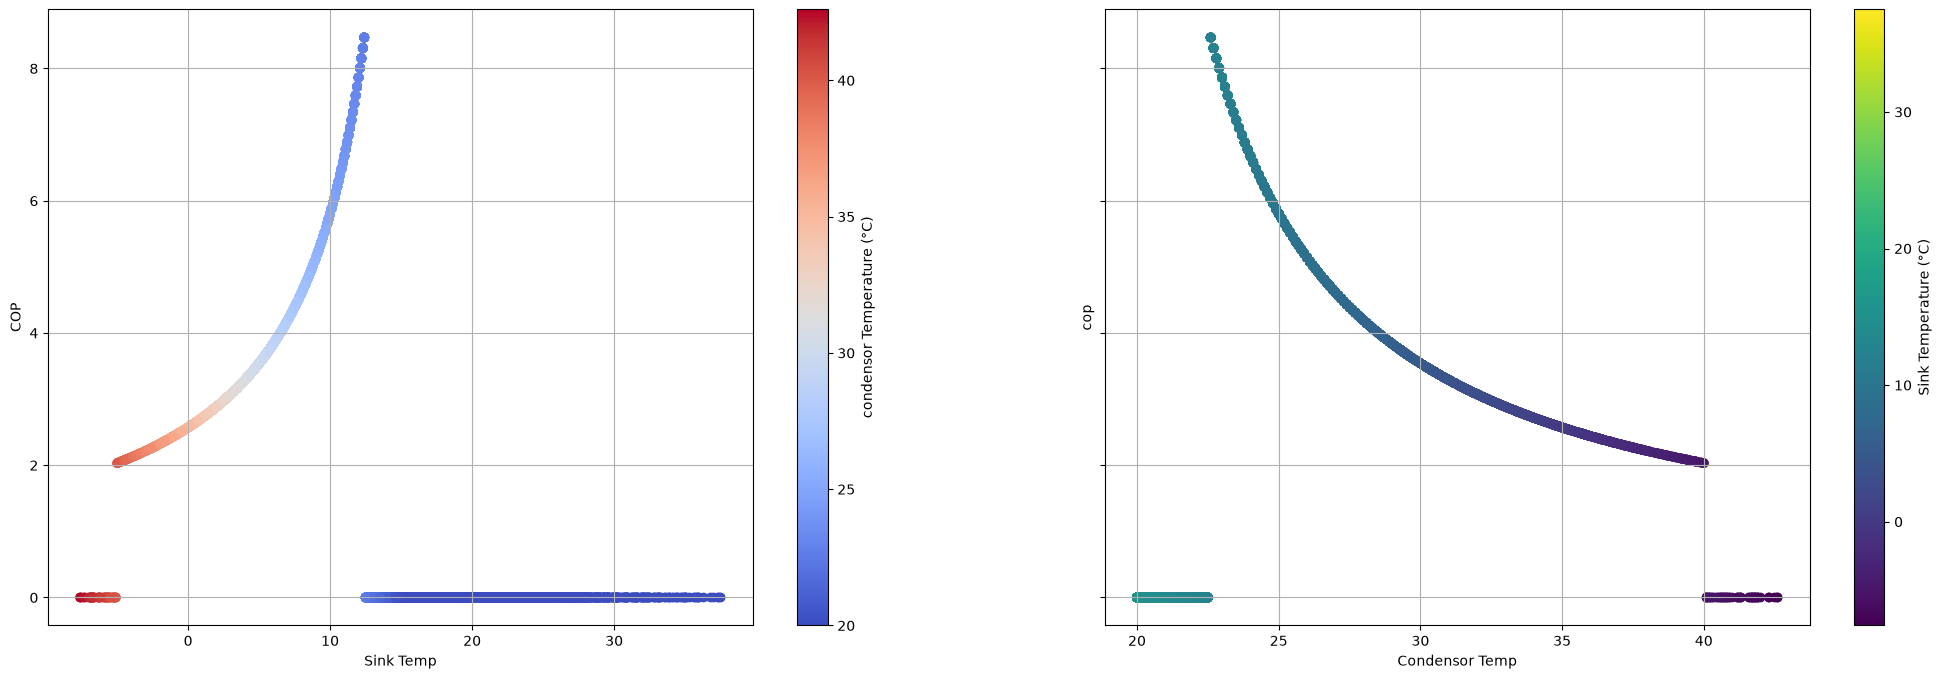

In [64]:
plot_COP_isights(a_w_lt)

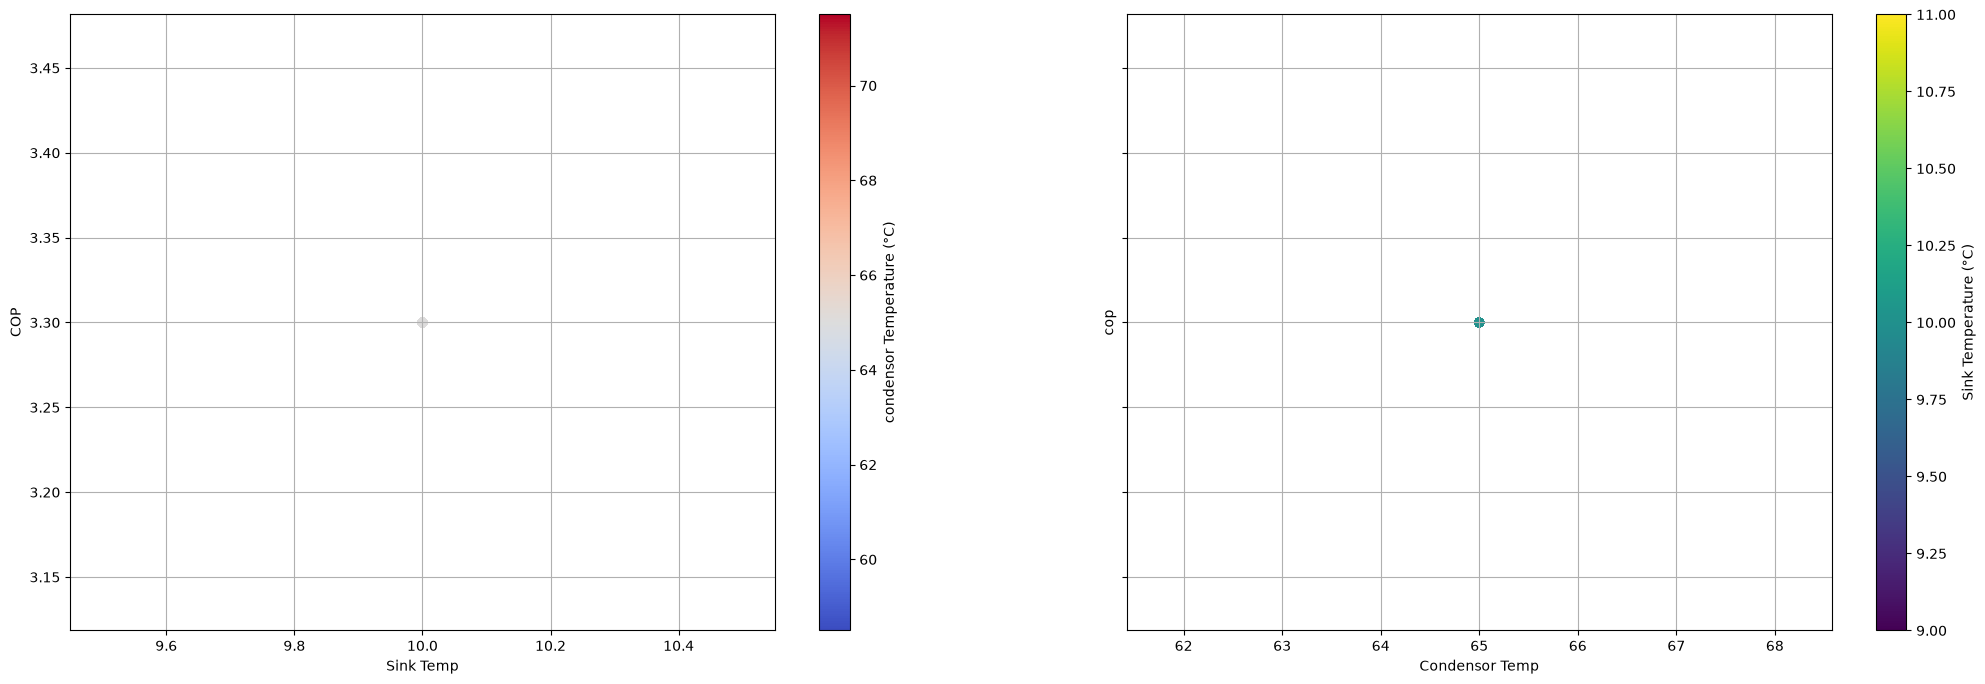

In [65]:
plot_COP_isights(b_w_ht)

## Exporting

In [66]:
a_w_lt['cop'].rename('a_w_lt_cop')

0       6.883243
1       6.883243
2       6.883243
3       6.777974
4       6.777974
          ...   
8755    0.000000
8756    0.000000
8757    0.000000
8758    0.000000
8759    0.000000
Name: a_w_lt_cop, Length: 8760, dtype: float64

In [68]:
import os
data = pd.read_excel(os.path.join(os.getcwd(), 'data', 'gen_profiles_pu.xlsx'), index_col = 0)

# data = pd.concat([data, a_w_lt['cop'].rename('a_w_lt_cop'), b_w_ht['cop'].rename('b_w_ht_cop')], axis=1, ignore_index=True)
data

,Roof_pv,HP_COP
snapshot,,
2026-01-01 00:00:00,0.0,2.5
2026-01-01 01:00:00,0.0,2.4
2026-01-01 02:00:00,0.0,2.4
2026-01-01 03:00:00,0.0,2.3
2026-01-01 04:00:00,0.0,2.3
...,...,...
2026-12-31 19:00:00,0.0,2.8
2026-12-31 20:00:00,0.0,2.7
2026-12-31 21:00:00,0.0,2.6
